# MSML606 HW-3

### AI tools (ChatGPT, Claude) were used for general understanding and clarification of concepts (trees, stacks).

## Part I: Hash table implementation

## Problem 1. Implement a hash table.

In [1]:
import time
import random
import matplotlib.pyplot as plt

class HashMap:
    def __init__(self, size=101):
        self.size = size
        self.table = []
        self.count = 0
        self.hash_method = "division"
        for _ in range(size):
            self.table.append([])   # each is a list

    def _key_to_int(self, key):
        # convert key into a number
        if type(key) == int:
            return abs(key)
        elif type(key) == str:
            total = 0
            for ch in key:
                total = total + ord(ch)
            return total
        else:
            # edge case
            text = str(key)
            total = 0
            for ch in text:
                total = total + ord(ch)
            return total

    # retrieve value
    def search(self, key):
        index = self._hash(key, self.hash_method)
        chain = self.table[index]
        for pair in chain:
            if pair[0] == key:
                return pair[1]
        return None

    # insert into the hash table
    def insert(self, key, value):
        index = self._hash(key, self.hash_method)
        chain = self.table[index]
        # update if key already exists
        for i in range(len(chain)):
            if chain[i][0] == key:
                chain[i] = (key, value)
                return
        chain.append((key, value))
        self.count += 1

    # remove the key value pair from table
    def delete(self, key):
        index = self._hash(key, self.hash_method)
        chain = self.table[index]

        for i in range(len(chain)):
            if chain[i][0] == key:
                del chain[i]
                self.count -= 1
                return True

        return False

    def dynamicResizing(self):
        pass

    # hashing methods
    def _hash(self, key, method="division"):
        num = self._key_to_int(key)

        # division
        if method == "division":
            return num % self.size

        # multiplication
        elif method == "multiplication":
            a = 0.618
            frac = (num * a) % 1
            return int(self.size * frac)

        # default case
        return num % self.size

    def load_factor(self):
        return self.count / self.size

    def average_chain_length(self):
        total = 0
        for chain in self.table:
            total += len(chain)
        return total / self.size

    def max_chain_length(self):
        longest = 0
        for chain in self.table:
            if len(chain) > longest:
                longest = len(chain)
        return longest



## Problem 2. Performance Analysis

Search apple: 10
Search banana: 20
After delete banana: None
Method: division | Size: 101 | Load Factor: 0.25 | Success Time: 4.5167999815021174e-07 | Fail Time: 3.1211999612423824e-07
Method: division | Size: 101 | Load Factor: 0.5 | Success Time: 3.2617999977446745e-07 | Fail Time: 2.893999999287189e-07
Method: division | Size: 101 | Load Factor: 0.75 | Success Time: 4.018266675605749e-07 | Fail Time: 2.910800003519398e-07
Method: division | Size: 101 | Load Factor: 1.0 | Success Time: 3.472999992482073e-07 | Fail Time: 3.215200001704943e-07
Method: division | Size: 101 | Load Factor: 1.25 | Success Time: 3.228799994303699e-07 | Fail Time: 3.0649999985143947e-07


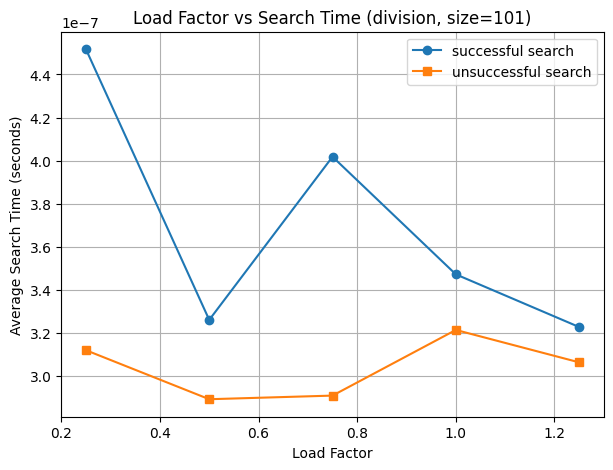

Method: division | Size: 503 | Load Factor: 0.25 | Success Time: 8.525000009740324e-07 | Fail Time: 5.293399999573012e-07
Method: division | Size: 503 | Load Factor: 0.5 | Success Time: 1.7714800003432173e-06 | Fail Time: 5.429100008313981e-07
Method: division | Size: 503 | Load Factor: 0.75 | Success Time: 3.662699998585595e-07 | Fail Time: 3.284900003563962e-07
Method: division | Size: 503 | Load Factor: 1.0 | Success Time: 3.807099994901364e-07 | Fail Time: 3.312000001187698e-07
Method: division | Size: 503 | Load Factor: 1.25 | Success Time: 3.7223999925117825e-07 | Fail Time: 3.4727999945971535e-07


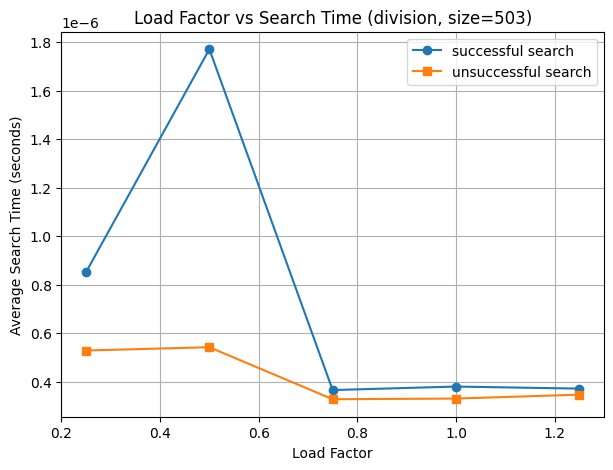

Method: division | Size: 1009 | Load Factor: 0.25 | Success Time: 3.500299999359413e-07 | Fail Time: 3.256700006204483e-07
Method: division | Size: 1009 | Load Factor: 0.5 | Success Time: 3.5269000022708494e-07 | Fail Time: 3.25290000091627e-07
Method: division | Size: 1009 | Load Factor: 0.75 | Success Time: 3.60179999461252e-07 | Fail Time: 3.2034000014391494e-07
Method: division | Size: 1009 | Load Factor: 1.0 | Success Time: 3.8527000015164956e-07 | Fail Time: 3.302900006474374e-07
Method: division | Size: 1009 | Load Factor: 1.25 | Success Time: 9.291000003486261e-07 | Fail Time: 6.344600001284561e-07


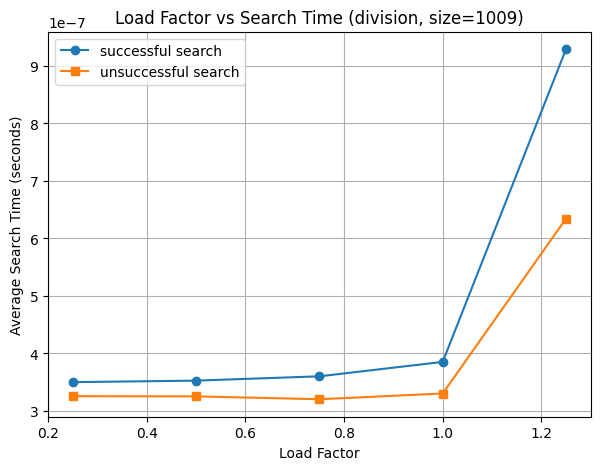

Method: multiplication | Size: 101 | Load Factor: 0.25 | Success Time: 1.0781599985421054e-06 | Fail Time: 2.866999998332176e-06
Method: multiplication | Size: 101 | Load Factor: 0.5 | Success Time: 1.6329599998243794e-06 | Fail Time: 1.1720399993464525e-06
Method: multiplication | Size: 101 | Load Factor: 0.75 | Success Time: 1.4837733336510914e-06 | Fail Time: 1.3800533330747082e-06
Method: multiplication | Size: 101 | Load Factor: 1.0 | Success Time: 1.3766999995823425e-06 | Fail Time: 9.46069999372412e-07
Method: multiplication | Size: 101 | Load Factor: 1.25 | Success Time: 9.774200009360356e-07 | Fail Time: 9.530099998755759e-07


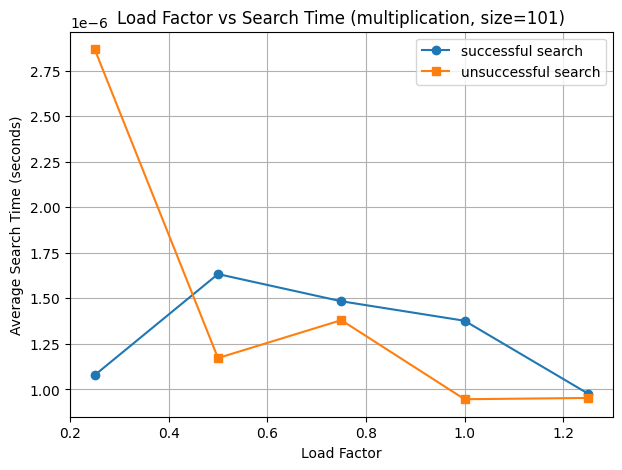

Method: multiplication | Size: 503 | Load Factor: 0.25 | Success Time: 6.796599996050645e-07 | Fail Time: 5.949799992777116e-07
Method: multiplication | Size: 503 | Load Factor: 0.5 | Success Time: 6.237299999156675e-07 | Fail Time: 6.009200001244608e-07
Method: multiplication | Size: 503 | Load Factor: 0.75 | Success Time: 1.0896399999182905e-06 | Fail Time: 6.95890000770305e-07
Method: multiplication | Size: 503 | Load Factor: 1.0 | Success Time: 4.384320000099251e-06 | Fail Time: 1.070130000471181e-06
Method: multiplication | Size: 503 | Load Factor: 1.25 | Success Time: 1.0217599992756732e-06 | Fail Time: 9.914999998272834e-07


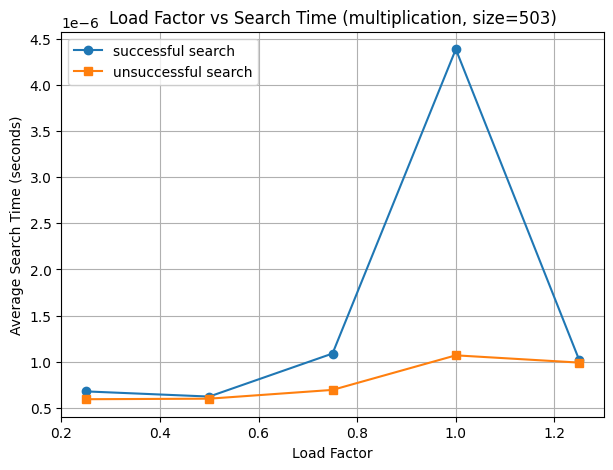

Method: multiplication | Size: 1009 | Load Factor: 0.25 | Success Time: 6.162800002584845e-07 | Fail Time: 6.676099997093843e-07
Method: multiplication | Size: 1009 | Load Factor: 0.5 | Success Time: 6.231600002593041e-07 | Fail Time: 6.296699996255483e-07
Method: multiplication | Size: 1009 | Load Factor: 0.75 | Success Time: 6.491400006325421e-07 | Fail Time: 6.346800000756048e-07
Method: multiplication | Size: 1009 | Load Factor: 1.0 | Success Time: 6.580000001576991e-07 | Fail Time: 7.060100006128777e-07
Method: multiplication | Size: 1009 | Load Factor: 1.25 | Success Time: 7.896399995388492e-07 | Fail Time: 7.56809999984398e-07


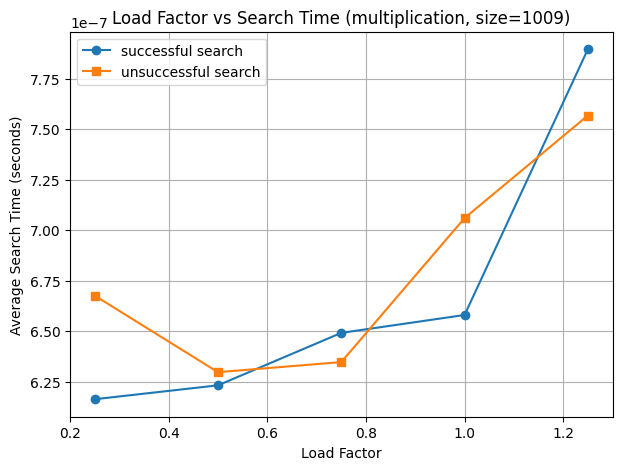


Distribution: uniform
Method: division
Successful search time: 3.6304999980529827e-07
Unsuccessful search time: 3.5453999998935613e-07
Average chain length: 0.7495029821073559
Maximum chain length: 4

Distribution: skewed
Method: division
Successful search time: 3.3694999956424e-07
Unsuccessful search time: 3.0597999966630596e-07
Average chain length: 0.35785288270377735
Maximum chain length: 2

Distribution: sequential
Method: division
Successful search time: 3.2216000022344816e-07
Unsuccessful search time: 3.1055000022206513e-07
Average chain length: 0.7495029821073559
Maximum chain length: 1

Distribution: uniform
Method: multiplication
Successful search time: 7.488500000363274e-07
Unsuccessful search time: 6.188400004702999e-07
Average chain length: 0.7495029821073559
Maximum chain length: 4

Distribution: skewed
Method: multiplication
Successful search time: 5.846999999903346e-07
Unsuccessful search time: 6.521299997075402e-07
Average chain length: 0.3101391650099404
Maximum chai

In [5]:
def generate_keys(distribution, n):
    keys = []

    if distribution == "uniform":
        for _ in range(n):
            keys.append(random.randint(1, 1000000))

    elif distribution == "skewed":
        for _ in range(n):
            if random.random() < 0.8:
                keys.append(random.randint(1, 100))
            else:
                keys.append(random.randint(101, 1000000))

    elif distribution == "sequential":
        for i in range(n):
            keys.append(i + 1)

    return keys


def measure_search_time(hashmap, keys):
    start = time.perf_counter()

    for key in keys:
        hashmap.search(key)

    end = time.perf_counter()

    if len(keys) == 0:
        return 0

    return (end - start) / len(keys)


def run_experiments():

    table_sizes = [101, 503, 1009]
    load_factors = [0.25, 0.50, 0.75, 1.0, 1.25]
    methods = ["division", "multiplication"]
    # Experiment 1
    # Load factor vs search time
    for method in methods:
        for size in table_sizes:
            good_times = []
            bad_times = []

            for lf in load_factors:
                h = HashMap(size)
                h.hash_method = method

                n = int(size * lf)
                keys = generate_keys("uniform", n)

                for key in keys:
                    h.insert(key, key * 10)

                # successful search
                if len(keys) > 100:
                    good_keys = random.sample(keys, 100)
                else:
                    good_keys = keys[:]

                # unsuccessful search
                bad_keys = []
                while len(bad_keys) < len(good_keys):
                    x = random.randint(2000000, 3000000)
                    bad_keys.append(x)

                t_good = measure_search_time(h, good_keys)
                t_bad = measure_search_time(h, bad_keys)

                good_times.append(t_good)
                bad_times.append(t_bad)

                print("Method:", method,
                      "| Size:", size,
                      "| Load Factor:", round(lf, 2),
                      "| Success Time:", t_good,
                      "| Fail Time:", t_bad)

            plt.figure(figsize=(7, 5))
            plt.plot(load_factors, good_times, marker='o', label='successful search')
            plt.plot(load_factors, bad_times, marker='s', label='unsuccessful search')
            plt.xlabel("Load Factor")
            plt.ylabel("Average Search Time (seconds)")
            plt.title("Load Factor vs Search Time (" + method + ", size=" + str(size) + ")")
            plt.legend()
            plt.grid(True)
            plt.show()

    # Experiment 2
    # Key distribution comparisons
    fixed_size = 503
    fixed_load_factor = 0.75
    n = int(fixed_size * fixed_load_factor)

    distributions = ["uniform", "skewed", "sequential"]

    for method in methods:
        success_result = []
        fail_result = []
        avg_chain_result = []
        max_chain_result = []

        for dist in distributions:
            h = HashMap(fixed_size)
            h.hash_method = method

            keys = generate_keys(dist, n)

            for key in keys:
                h.insert(key, key * 10)

            if len(keys) > 100:
                good_keys = random.sample(keys, 100)
            else:
                good_keys = keys[:]

            bad_keys = []
            while len(bad_keys) < len(good_keys):
                x = random.randint(2000000, 3000000)
                bad_keys.append(x)

            t_good = measure_search_time(h, good_keys)
            t_bad = measure_search_time(h, bad_keys)

            success_result.append(t_good)
            fail_result.append(t_bad)
            avg_chain_result.append(h.average_chain_length())
            max_chain_result.append(h.max_chain_length())

            print("\nDistribution:", dist)
            print("Method:", method)
            print("Successful search time:", t_good)
            print("Unsuccessful search time:", t_bad)
            print("Average chain length:", h.average_chain_length())
            print("Maximum chain length:", h.max_chain_length())




# example test
if __name__ == "__main__":
    h = HashMap(11)
    h.hash_method = "division"

    h.insert("apple", 10)
    h.insert("banana", 20)
    h.insert("orange", 30)

    print("Search apple:", h.search("apple"))
    print("Search banana:", h.search("banana"))

    h.delete("banana")
    print("After delete banana:", h.search("banana"))

    run_experiments()